In [16]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

In [17]:
N = 4
wm = 1.0
wd = 0.642570281124498
tlist = np.linspace(0, 50, 100)
dlist = np.linspace(0.0, 2.0, 35)
alist = np.linspace(0.1, 2.5, 35)

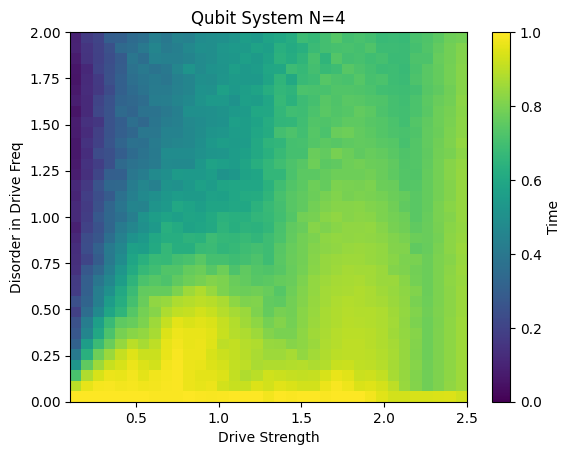

In [18]:
qH0, qH1_list, wm = get_random_freq_qubit_ham(N)
qeigenvalues, qeigenstates = qH0.eigenstates()

qdisRtau = []
for disorder in dlist:
    qampRtau = []
    for amp in alist:
        Rtau_qubit = []
        qargs = {"A": amp}
        for _ in range(50):
            dw = np.random.uniform(-disorder, disorder, N)
            omega_list = wm + dw
            qH = [qH0]

            for r in range(N):
                qargs[f"wd{r}"] = omega_list[r]
                qH.append([qH1_list[r], make_coeff(r)])

            qH = qt.QobjEvo(qH, args=qargs)
            qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
            Rtau_qubit.append(np.array(np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / (qeigenvalues[-1] - qeigenvalues[0])))
        Rtau_qubit = np.array(Rtau_qubit)
        Rtau_qubit = np.mean(Rtau_qubit, axis=0)
        qampRtau.append(np.max(Rtau_qubit))
    qdisRtau.append(qampRtau)

plt.imshow(qdisRtau,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label="Time")
plt.title(f"Qubit System N={N}")
plt.ylabel("Disorder in Drive Freq")
plt.xlabel("Drive Strength")
plt.show()

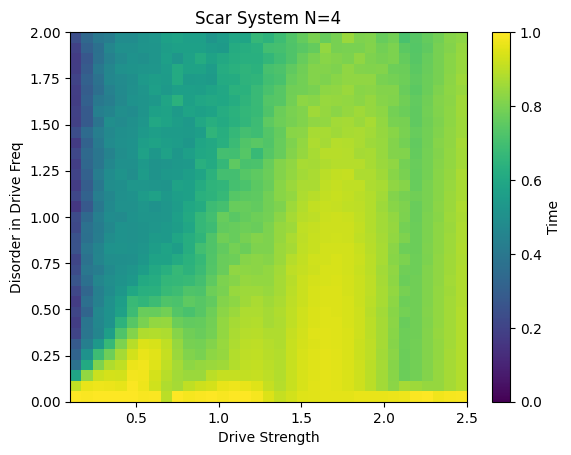

In [19]:
H0, H1_list, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, random_drive_freq=True)

disRtau = []
for disorder in dlist:
    ampRtau = []
    for amp in alist:
        Rtau_scar = []
        args = {"A": amp}
        for _ in range(50):
            dw = np.random.uniform(-disorder, disorder, N)
            omega_list = wd + dw
            H = [H0]

            for r in range(N):
                args[f"wd{r}"] = omega_list[r]
                H.append([H1_list[r], make_coeff(r)])

            H = qt.QobjEvo(H, args=args)
            psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
            Rtau_scar.append(np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0])))
        Rtau_scar = np.array(Rtau_scar)
        Rtau_scar = np.mean(Rtau_scar, axis=0)
        ampRtau.append(np.max(Rtau_scar))
    disRtau.append(ampRtau)

plt.imshow(disRtau,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label="Time")
plt.title(f"Scar System N={N}")
plt.ylabel("Disorder in Drive Freq")
plt.xlabel("Drive Strength")
plt.show()

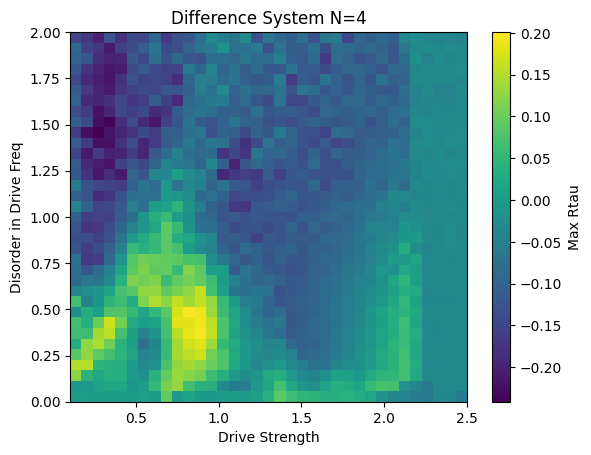

In [21]:
plt.imshow(np.array(qdisRtau) - np.array(disRtau),
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis') # , vmin=-0.3, vmax=0.3
plt.colorbar(label="Max Rtau")
plt.title(f"Difference System N={N}")
plt.ylabel("Disorder in Drive Freq")
plt.xlabel("Drive Strength")
plt.show()